In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv("cleaned_hotel_bookings.csv")

print("Dataset loaded successfully!")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

Dataset loaded successfully!
Rows: 87396
Columns: 39


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,reservation_status,reservation_status_date,arrival_month_number,arrival_date,total_nights,total_guests,cancellation_flag,stay_duration_category,lead_time_category,estimated_room_value
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Check-Out,2015-07-01,7,2015-07-01,0,2.0,0,Short,Long,0.0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Check-Out,2015-07-01,7,2015-07-01,0,2.0,0,Short,Long,0.0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Check-Out,2015-07-02,7,2015-07-01,1,1.0,0,Short,Very Short,75.0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Check-Out,2015-07-02,7,2015-07-01,1,1.0,0,Short,Short,75.0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Check-Out,2015-07-03,7,2015-07-01,2,2.0,0,Short,Short,196.0


In [5]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (87396, 39)

Column Names:
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date', 'arrival_month_number', 'arrival_date', 'total_nights', 'total_guests', 'cancellation_flag', 'stay_duration_category', 'lead_time_category', 'estimated_room_value']

Missing Values:
0

Duplicate Rows:
7


In [9]:
df["arrival_date"] = pd.to_datetime(
    df["arrival_date"],
    errors="coerce"
)

month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

df["arrival_date_month"] = pd.Categorical(
    df["arrival_date_month"],
    categories=month_order,
    ordered=True
)

df["realized_room_value"] = np.where(
    df["cancellation_flag"] == 0,
    df["estimated_room_value"],
    0
)

print("Data preparation completed.")

Data preparation completed.


In [11]:
total_bookings = len(df)

cancelled_bookings = df["cancellation_flag"].sum()

completed_bookings = total_bookings - cancelled_bookings

cancellation_rate = (
    cancelled_bookings / total_bookings
) * 100

average_adr = df["adr"].mean()

average_length_of_stay = df["total_nights"].mean()

total_realized_value = df["realized_room_value"].sum()

average_revenue_per_completed_booking = (
    total_realized_value / completed_bookings
)

print("========== KEY BUSINESS KPIs ==========")

print("Total Bookings:", f"{total_bookings:,}")
print("Completed Bookings:", f"{completed_bookings:,}")
print("Cancelled Bookings:", f"{cancelled_bookings:,}")
print("Cancellation Rate:", f"{cancellation_rate:.2f}%")
print("Average ADR:", f"{average_adr:.2f}")
print(
    "Average Length of Stay:",
    f"{average_length_of_stay:.2f} nights"
)
print(
    "Total Realized Room Value:",
    f"{total_realized_value:,.2f}"
)
print(
    "Average Revenue per Completed Booking:",
    f"{average_revenue_per_completed_booking:.2f}"
)

========== KEY BUSINESS KPIs ==========
Total Bookings: 87,396
Completed Bookings: 63,371
Cancelled Bookings: 24,025
Cancellation Rate: 27.49%
Average ADR: 106.34
Average Length of Stay: 3.63 nights
Total Realized Room Value: 22,977,941.13
Average Revenue per Completed Booking: 362.59


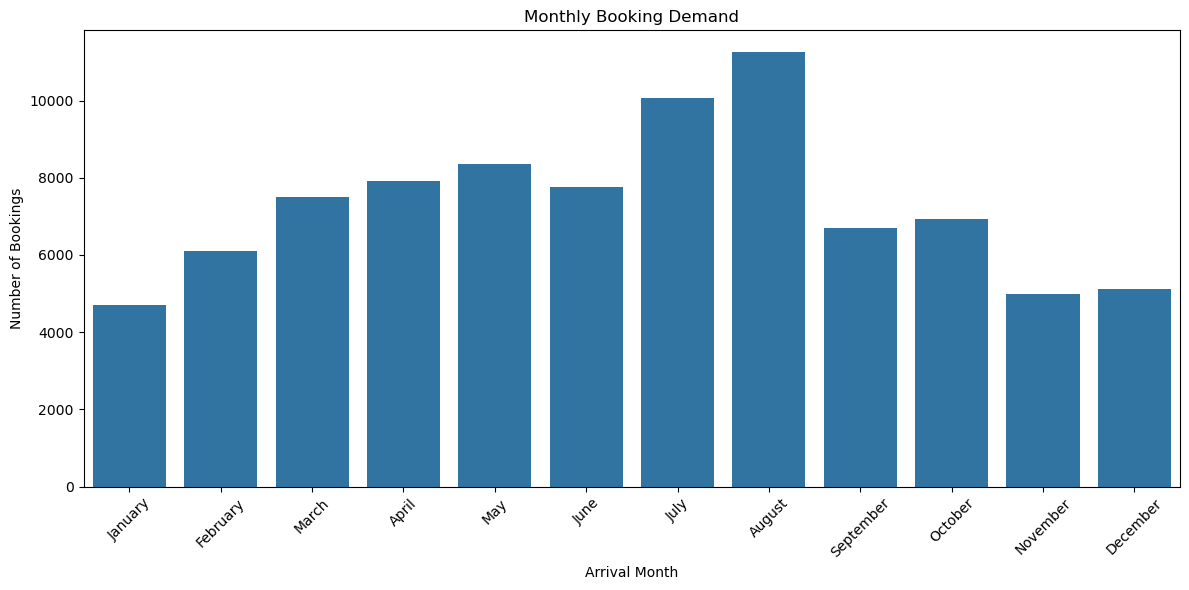

In [13]:
monthly_bookings = (
    df.groupby(
        "arrival_date_month",
        observed=False
    )
    .size()
    .reindex(month_order)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=monthly_bookings.index,
    y=monthly_bookings.values
)

plt.title("Monthly Booking Demand")
plt.xlabel("Arrival Month")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [15]:
highest_booking_month = monthly_bookings.idxmax()
highest_booking_value = monthly_bookings.max()

lowest_booking_month = monthly_bookings.idxmin()
lowest_booking_value = monthly_bookings.min()

print("========== INSIGHT ==========")

print(
    f"Highest booking demand occurs in "
    f"{highest_booking_month} with "
    f"{highest_booking_value:,} bookings."
)

print(
    f"Lowest booking demand occurs in "
    f"{lowest_booking_month} with "
    f"{lowest_booking_value:,} bookings."
)

========== INSIGHT ==========
Highest booking demand occurs in August with 11,257 bookings.
Lowest booking demand occurs in January with 4,693 bookings.


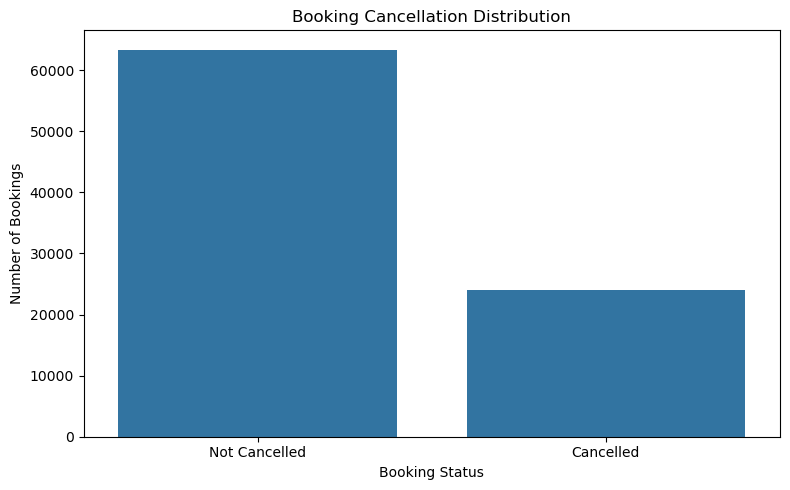

In [17]:
cancellation_counts = (
    df["cancellation_flag"]
    .value_counts()
    .sort_index()
)

labels = [
    "Not Cancelled",
    "Cancelled"
]

values = [
    cancellation_counts.get(0, 0),
    cancellation_counts.get(1, 0)
]

plt.figure(figsize=(8, 5))

sns.barplot(
    x=labels,
    y=values
)

plt.title("Booking Cancellation Distribution")
plt.xlabel("Booking Status")
plt.ylabel("Number of Bookings")

plt.tight_layout()
plt.show()

In [19]:
print("========== INSIGHT ==========")

print(
    f"The overall cancellation rate is "
    f"{cancellation_rate:.2f}%."
)

print(
    f"There are {cancelled_bookings:,} cancelled bookings "
    f"out of {total_bookings:,} total bookings."
)

========== INSIGHT ==========
The overall cancellation rate is 27.49%.
There are 24,025 cancelled bookings out of 87,396 total bookings.


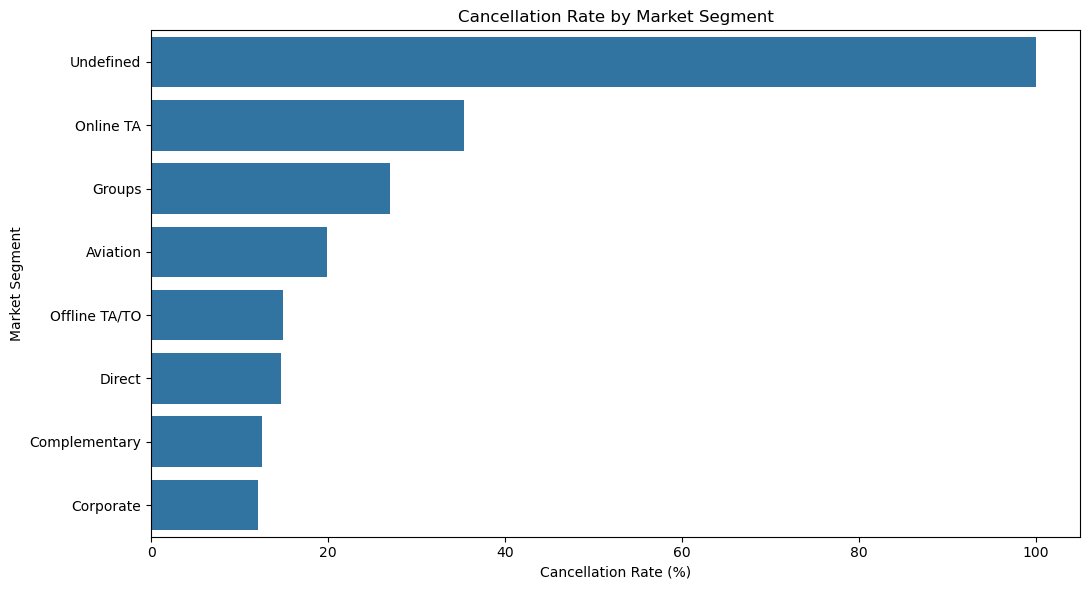

In [23]:
segment_cancellation = (
    df.groupby("market_segment")["cancellation_flag"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(11, 6))

sns.barplot(
    x=segment_cancellation.values,
    y=segment_cancellation.index
)

plt.title("Cancellation Rate by Market Segment")
plt.xlabel("Cancellation Rate (%)")
plt.ylabel("Market Segment")

plt.tight_layout()
plt.show()

In [25]:
highest_segment = segment_cancellation.idxmax()
highest_segment_rate = segment_cancellation.max()

lowest_segment = segment_cancellation.idxmin()
lowest_segment_rate = segment_cancellation.min()

print("========== INSIGHT ==========")

print(
    f"Highest cancellation rate: {highest_segment} "
    f"({highest_segment_rate:.2f}%)."
)

print(
    f"Lowest cancellation rate: {lowest_segment} "
    f"({lowest_segment_rate:.2f}%)."
)

========== INSIGHT ==========
Highest cancellation rate: Undefined (100.00%).
Lowest cancellation rate: Corporate (12.11%).


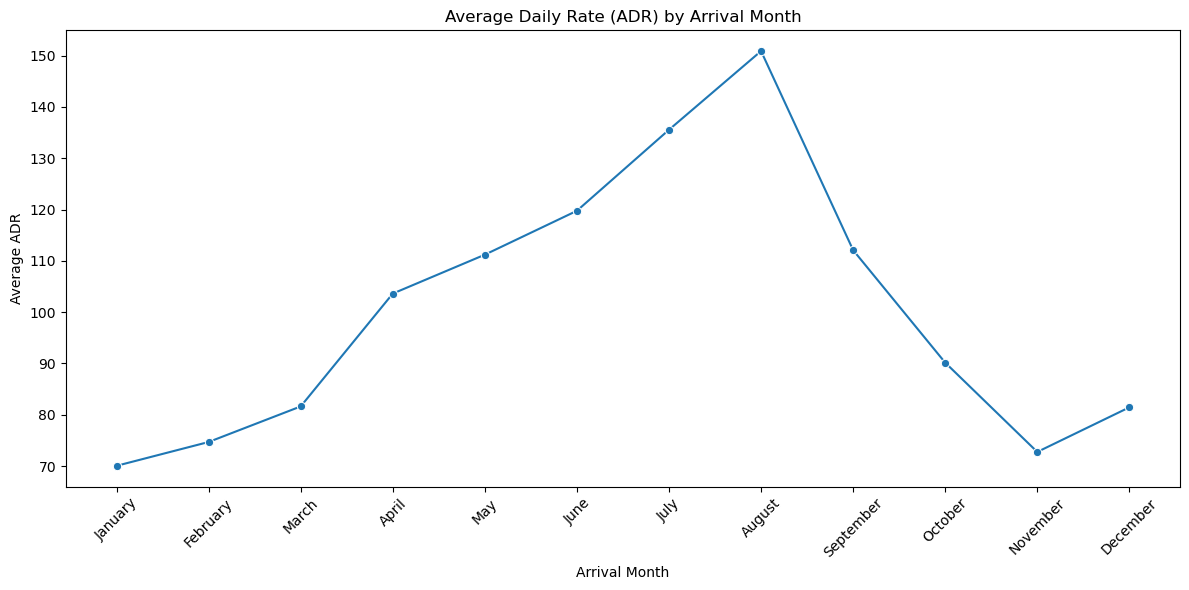

In [27]:
monthly_adr = (
    df.groupby(
        "arrival_date_month",
        observed=False
    )["adr"]
    .mean()
    .reindex(month_order)
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    x=monthly_adr.index,
    y=monthly_adr.values,
    marker="o"
)

plt.title("Average Daily Rate (ADR) by Arrival Month")
plt.xlabel("Arrival Month")
plt.ylabel("Average ADR")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [29]:
highest_adr_month = monthly_adr.idxmax()
highest_adr_value = monthly_adr.max()

lowest_adr_month = monthly_adr.idxmin()
lowest_adr_value = monthly_adr.min()

print("========== INSIGHT ==========")

print(
    f"Highest average ADR occurs in {highest_adr_month} "
    f"with an ADR of {highest_adr_value:.2f}."
)

print(
    f"Lowest average ADR occurs in {lowest_adr_month} "
    f"with an ADR of {lowest_adr_value:.2f}."
)

========== INSIGHT ==========
Highest average ADR occurs in August with an ADR of 150.88.
Lowest average ADR occurs in January with an ADR of 70.05.


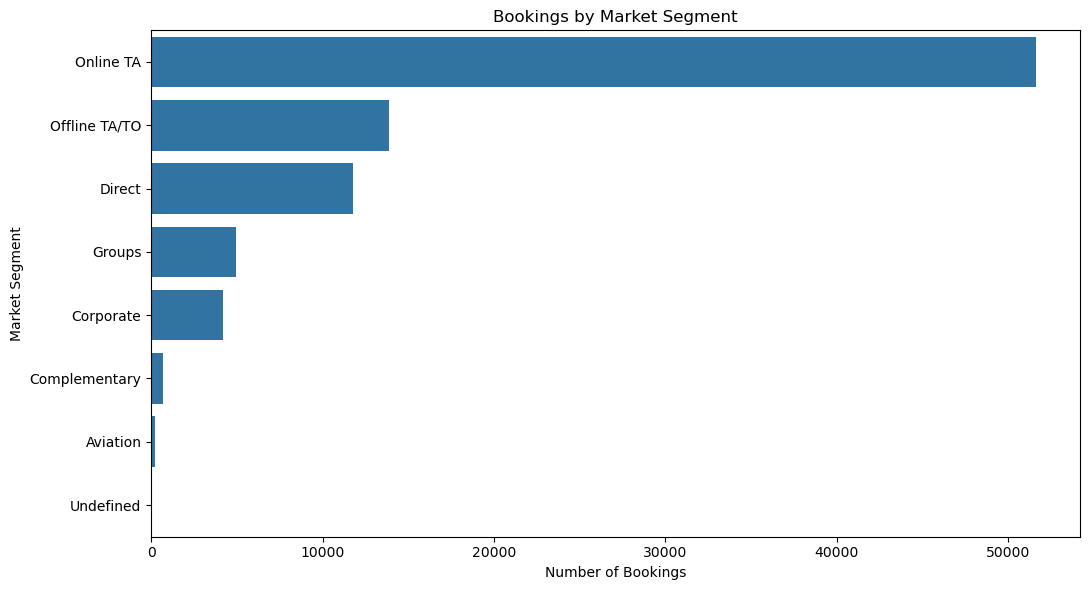

In [31]:
segment_bookings = (
    df["market_segment"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(11, 6))

sns.barplot(
    x=segment_bookings.values,
    y=segment_bookings.index
)

plt.title("Bookings by Market Segment")
plt.xlabel("Number of Bookings")
plt.ylabel("Market Segment")

plt.tight_layout()
plt.show()

In [33]:
top_booking_segment = segment_bookings.idxmax()

print("========== INSIGHT ==========")

print(
    f"The {top_booking_segment} market segment "
    f"has the highest number of bookings with "
    f"{segment_bookings.max():,} bookings."
)

========== INSIGHT ==========
The Online TA market segment has the highest number of bookings with 51,618 bookings.


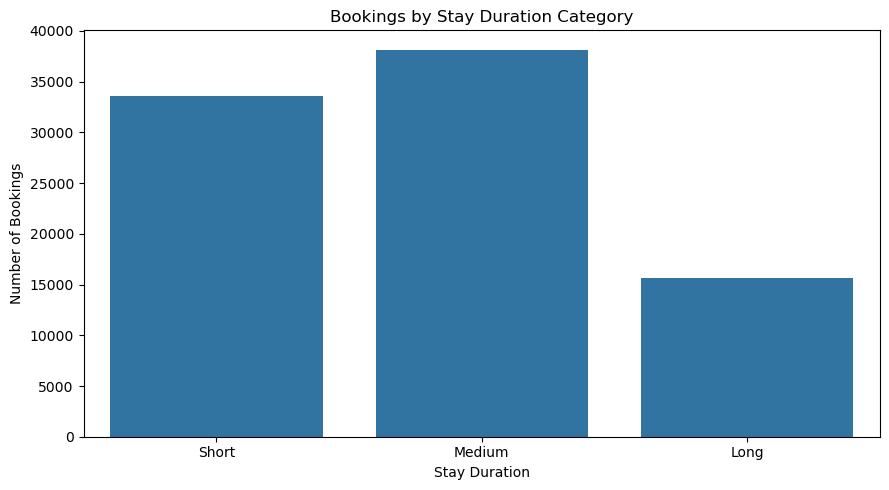

In [35]:
stay_order = [
    "Short",
    "Medium",
    "Long"
]

stay_counts = (
    df["stay_duration_category"]
    .value_counts()
    .reindex(stay_order)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=stay_counts.index,
    y=stay_counts.values
)

plt.title("Bookings by Stay Duration Category")
plt.xlabel("Stay Duration")
plt.ylabel("Number of Bookings")

plt.tight_layout()
plt.show()

In [37]:
most_common_stay = stay_counts.idxmax()

print("========== INSIGHT ==========")

print(
    f"The most common stay category is "
    f"{most_common_stay} with "
    f"{stay_counts.max():,} bookings."
)

========== INSIGHT ==========
The most common stay category is Medium with 38,156 bookings.


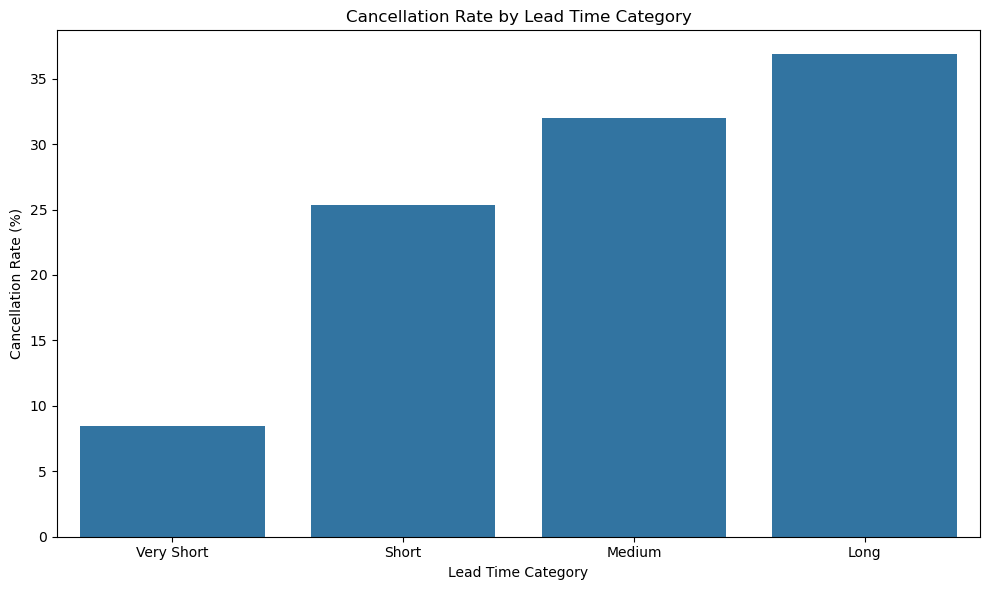

In [39]:
lead_order = [
    "Very Short",
    "Short",
    "Medium",
    "Long"
]

lead_cancellation = (
    df.groupby(
        "lead_time_category",
        observed=False
    )["cancellation_flag"]
    .mean()
    .mul(100)
    .reindex(lead_order)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=lead_cancellation.index,
    y=lead_cancellation.values
)

plt.title("Cancellation Rate by Lead Time Category")
plt.xlabel("Lead Time Category")
plt.ylabel("Cancellation Rate (%)")

plt.tight_layout()
plt.show()

In [41]:
highest_lead_category = lead_cancellation.idxmax()
highest_lead_rate = lead_cancellation.max()

print("========== INSIGHT ==========")

print(
    f"The {highest_lead_category} lead-time category "
    f"has the highest cancellation rate at "
    f"{highest_lead_rate:.2f}%."
)

========== INSIGHT ==========
The Long lead-time category has the highest cancellation rate at 36.85%.


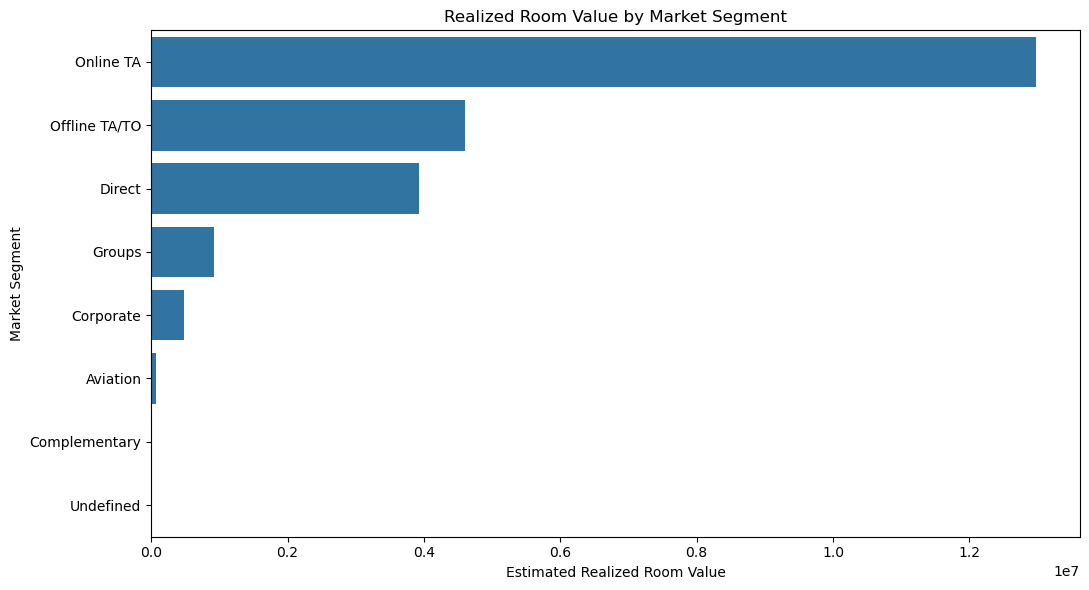

In [43]:
segment_revenue = (
    df.groupby("market_segment")["realized_room_value"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(11, 6))

sns.barplot(
    x=segment_revenue.values,
    y=segment_revenue.index
)

plt.title("Realized Room Value by Market Segment")
plt.xlabel("Estimated Realized Room Value")
plt.ylabel("Market Segment")

plt.tight_layout()
plt.show()

In [45]:
top_revenue_segment = segment_revenue.idxmax()
top_revenue_value = segment_revenue.max()

print("========== INSIGHT ==========")

print(
    f"The {top_revenue_segment} market segment "
    f"has the highest realized room value of "
    f"{top_revenue_value:,.2f}."
)

========== INSIGHT ==========
The Online TA market segment has the highest realized room value of 12,973,686.94.


In [47]:
summary_table = pd.DataFrame({
    "Metric": [
        "Total Bookings",
        "Completed Bookings",
        "Cancelled Bookings",
        "Cancellation Rate (%)",
        "Average ADR",
        "Average Length of Stay",
        "Total Realized Room Value",
        "Average Revenue per Completed Booking"
    ],

    "Value": [
        total_bookings,
        completed_bookings,
        cancelled_bookings,
        round(cancellation_rate, 2),
        round(average_adr, 2),
        round(average_length_of_stay, 2),
        round(total_realized_value, 2),
        round(average_revenue_per_completed_booking, 2)
    ]
})

display(summary_table)

,Metric,Value
0,Total Bookings,87396.00
1,Completed Bookings,63371.00
2,Cancelled Bookings,24025.00
3,Cancellation Rate (%),27.49
4,Average ADR,106.34
5,Average Length of Stay,3.63
6,Total Realized Room Value,22977941.13
7,Average Revenue per Completed Booking,362.59


In [49]:
print("================================================")
print("          TASK 3 BUSINESS INSIGHTS")
print("================================================")

print(
    f"1. {highest_booking_month} has the highest booking demand."
)

print(
    f"2. The overall cancellation rate is "
    f"{cancellation_rate:.2f}%."
)

print(
    f"3. {highest_segment} has the highest cancellation rate "
    f"among market segments."
)

print(
    f"4. {highest_adr_month} records the highest average ADR."
)

print(
    f"5. {top_booking_segment} has the highest booking volume."
)

print(
    f"6. {most_common_stay} is the most common stay-duration category."
)

print(
    f"7. {highest_lead_category} has the highest cancellation "
    f"rate by lead-time category."
)

print(
    f"8. {top_revenue_segment} has the highest realized room value."
)

          TASK 3 BUSINESS INSIGHTS
1. August has the highest booking demand.
2. The overall cancellation rate is 27.49%.
3. Undefined has the highest cancellation rate among market segments.
4. August records the highest average ADR.
5. Online TA has the highest booking volume.
6. Medium is the most common stay-duration category.
7. Long has the highest cancellation rate by lead-time category.
8. Online TA has the highest realized room value.


In [51]:
df.to_csv(
    "task3_visualization_data.csv",
    index=False
)

summary_table.to_csv(
    "task3_kpi_summary.csv",
    index=False
)

print("Task 3 processed data saved successfully!")
print("Task 3 KPI summary saved successfully!")

Task 3 processed data saved successfully!
Task 3 KPI summary saved successfully!
